# Исправление ошибок в алгоритмах для плагина

In [1]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import networkx as nx

import matplotlib.pyplot as plt

from shapely import unary_union

In [2]:
# bounds = gpd.read_file('tests\data\outter_borders.gpkg')
# bounds.boundary.plot()

In [3]:
# G = ox.graph_from_polygon(unary_union(bounds), network_type='drive_service')

In [4]:
# ox.plot_graph(G, edge_linewidth=0.2, node_size=0, edge_color='k', bgcolor='w', figsize=(10,10))

In [5]:
# ox.save_graphml(G, 'g_temp.ml')

# Тесты

In [6]:
from graphs.speeds import kmh_to_mm, set_graph_travel_times


G = ox.load_graphml('g_temp.ml')
speeds = [49, 37, 26, 16, 5]
set_graph_travel_times(G, speeds, morph_function=kmh_to_mm, travel_time_field='travel_time')
G = ox.project_graph(G)

d:\Git\genesis\work\genesis\graphs\speeds.py:98: UserWarning: Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. Рекомендуется устанавливать время следования для неупрощенного графа и только после этого упрощать
  warnings.warn("Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. " + \


<Axes: >

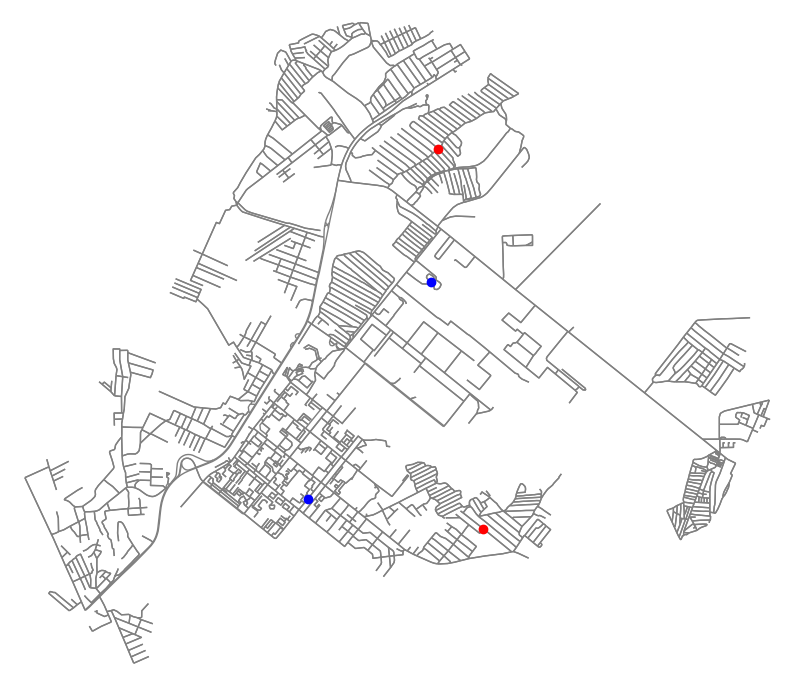

In [7]:
new_units = gpd.read_file(r'tests\data\new_units.gpkg')
existed_units = gpd.read_file(r'tests\data\stations.gpkg')

g_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)

new_units     = ox.project_gdf(new_units)
existed_units = ox.project_gdf(existed_units)

new_units['node'] = ox.nearest_nodes(G, new_units.geometry.x, new_units.geometry.y)
existed_units['node'] = ox.nearest_nodes(G, existed_units.geometry.x, existed_units.geometry.y)

fig, ax = ox.plot_graph(G, node_size=0, edge_color='grey', bgcolor='w', figsize=(10,10), show=False)
g_nodes.loc[new_units['node']].plot(ax=ax, color='r')
g_nodes.loc[existed_units['node']].plot(ax=ax, color='b')

# plt.show()

+
# эпоха 0: значение целевой метрики: 5.99770281415413.
# эпоха 1: значение целевой метрики: 5.634867529867624.
# эпоха 2: значение целевой метрики: 5.548167690040637.
# эпоха 3: значение целевой метрики: 5.496657403004288.
# эпоха 4: значение целевой метрики: 5.496657403004288.
# эпоха 5: значение целевой метрики: 5.496657403004288.
# эпоха 6: значение целевой метрики: 5.496657403004288.
# эпоха 7: значение целевой метрики: 5.496657403004288.
# эпоха 8: значение целевой метрики: 5.496657403004288.
# эпоха 9: значение целевой метрики: 5.496657403004288.
# эпоха 10: значение целевой метрики: 5.496657403004288.
# эпоха 11: значение целевой метрики: 5.496657403004288.
# эпоха 12: значение целевой метрики: 5.496657403004288.
# эпоха 13: значение целевой метрики: 5.451791481495662.
# эпоха 14: значение целевой метрики: 5.439809321879322.
# эпоха 15: значение целевой метрики: 5.439809321879322.
# эпоха 16: значение целевой метрики: 5.439809321879322.
# эпоха 17: значение целевой метрики: 5.

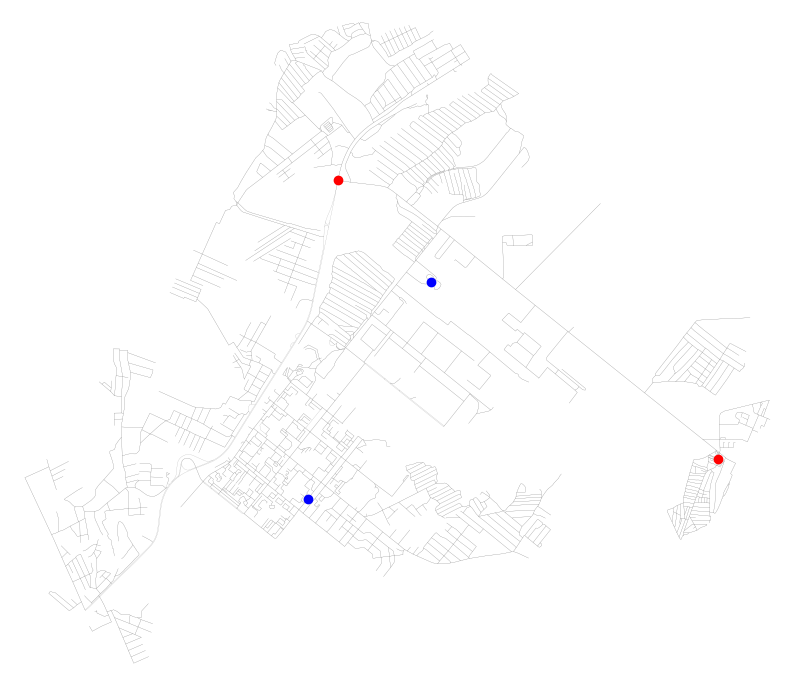

In [24]:
from fire_units.best_points import BestNodeHillClimbingHD
from fire_units.mclp import BestNodesGAKopt
from fire_units.metrics import ArrivalTimeBuilding, CoverIndexBuilding
from genesis.mclp import BestNodesKoptG
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.point_selectors import GenesisNodeSelector, RandomNodesSelector
from genesis.states import FirstArrivalUnitState

#====================================================================================
optimized_units_gdf = new_units
existed_units_gdf   = existed_units
# existed_units_gdf   = None

target_points_gdf = None
area_gdf          = None
optimized_metric  = 0


population_size    = 50
epochs             = 20
mutation_rate      = 0.5
elite_size         = 0
mutation_max_count = 3






#====================================================================================
def after_local_epoch(epoch, best_metric, **kwargs):
    print(f'# эпоха {epoch}: значение целевой метрики: {best_metric}.')
def after_iter(i, best_metric, **kwargs):
    print(f'## итерация {i}: значение целевой метрики: {best_metric}.')



## Определяем область для расчета, если передан area_layer (и получен area_gdf)
if not area_gdf is None:
    area_poly   = unary_union(area_gdf.geometry)
    g_nodes_gdf = ox.graph_to_gdfs(G, edges=False)
    area        = g_nodes_gdf.within(area_poly)
    nodes_list  = set(g_nodes_gdf[area].index)
else:
    area = None
    nodes_list = set(ox.graph_to_gdfs(G, edges=False).index)

## Определяем объекты алгоритма
metric_func = None
if target_points_gdf is None:
    if optimized_metric   == 0:
        metric_func  =  ArrivalTime()
    elif optimized_metric == 1:
        metric_func  =   CoverIndex()
    elif optimized_metric == 2:
        metric_func  = CoverIndex(20)
else:
    centroids                 = target_points_gdf.geometry.centroid
    target_points_gdf['node'] = ox.nearest_nodes(G, centroids.x, centroids.y)
    if optimized_metric   == 0:
        metric_func = ArrivalTimeBuilding(target_points_gdf)
    elif optimized_metric == 1:
        metric_func =  CoverIndexBuilding(target_points_gdf)
    elif optimized_metric == 2:
        metric_func  = CoverIndexBuilding(target_points_gdf, ip_val=20)


###  Структура алгоритма
bpf = BestNodeHillClimbingHD(FirstArrivalUnitState(),
                            metric_function=metric_func)
kopt = BestNodesKoptG(FirstArrivalUnitState(),
                    metric_function        = metric_func,
                    best_point_function    = bpf,
                    iterations             = 3,
                    iter_calc_end_function = after_iter)
# point_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_func)
point_selector = RandomNodesSelector(nodes_list=nodes_list)
mclp = BestNodesGAKopt(FirstArrivalUnitState(),
                        metric_function    = metric_func,
                        kopt_function      = kopt,
                        node_selector      = point_selector,
                        population_size    = population_size,
                        epochs             = epochs,
                        mutation_rate      = mutation_rate,
                        elite_size         = elite_size,
                        mutation_max_count = mutation_max_count,
                        epoch_end_function = after_local_epoch,
                        )


## Словари подразделений
optimized_units_gdf['node'] = ox.nearest_nodes(G, optimized_units_gdf.geometry.x, optimized_units_gdf.geometry.y)
# optimized_units_dict = {node:unit for node, unit in zip(optimized_units_gdf['node'], optimized_units_gdf['name'])}
optimized_units_dict = dict(zip(optimized_units_gdf['node'], optimized_units_gdf['name']))
existed_units_dict = None
if not existed_units_gdf is None:
    existed_units_gdf['node'] = ox.nearest_nodes(G, existed_units_gdf.geometry.x, existed_units_gdf.geometry.y)
    # existed_units_dict = {node:unit for node, unit in zip(existed_units_gdf['node'], existed_units_gdf['name'])}
    existed_units_dict = dict(zip(existed_units_gdf['node'], existed_units_gdf['name']))
    # print(optimized_units_dict)

## Проводим расчет
# feedback.setProgressText('Расчет оптимального размещения')
if len(optimized_units_dict) == 1:
    best_nodes, best_metric = kopt(env        = G,
                                dynamic_nodes = optimized_units_dict,
                                static_nodes  = existed_units_dict,
                                area          = area,
                                )
else:
    best_nodes, best_metric = mclp(env        = G,
                                dynamic_nodes = optimized_units_dict,
                                static_nodes  = existed_units_dict,
                                area          = area,
                                )


# Карта
# result_gdf = ox.graph_to_gdfs(G, edges=False).loc[best_nodes.keys()]

fig, ax = ox.plot_graph(G, node_size=0, edge_color='grey', bgcolor='w', figsize=(10,10), edge_linewidth=0.1, show=False)
g_nodes.loc[best_nodes.keys()].plot(ax=ax, color='r')
if existed_units_dict is not None:
    g_nodes.loc[existed_units_dict.keys()].plot(ax=ax, color='b')

# plt.show()